Step 1: Generating mock dataset...
-> Mock dataset 'sales_data.csv' created successfully.

Step 2: Performing ABC Analysis...
-> ABC Classification completed.

Step 3: Generating Visualizations...
-> Chart saved as 'abc_pie_chart.png'.
-> Final results saved as 'abc_analysis_results.csv'. Project executed successfully!


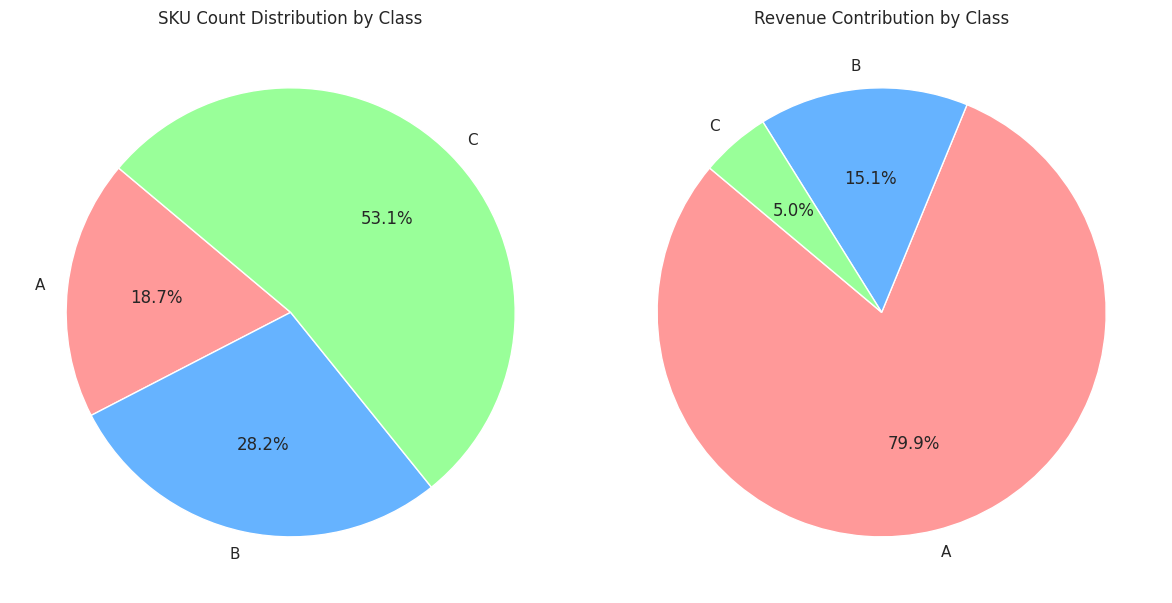

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 1: GENERATE MOCK SALES DATA
# ==========================================
print("Step 1: Generating mock dataset...")
np.random.seed(42) # Ensure reproducibility

# Generate 1000 SKUs (Stock Keeping Units)
skus = ['SKU_' + str(i).zfill(4) for i in range(1, 1001)]
prices = np.random.uniform(10, 500, 1000)

# Simulate Pareto distribution for sales quantities (80/20 rule)
quantities = np.random.pareto(a=1.5, size=1000) * 100
quantities = np.round(quantities).astype(int) + 1

# Create DataFrame and save to CSV
df = pd.DataFrame({
    'SKU': skus,
    'Price': np.round(prices, 2),
    'Quantity_Sold': quantities
})
df.to_csv('sales_data.csv', index=False)
print("-> Mock dataset 'sales_data.csv' created successfully.\n")

# ==========================================
# STEP 2: ABC CLASSIFICATION CORE LOGIC
# ==========================================
print("Step 2: Performing ABC Analysis...")
# Calculate Total Revenue per SKU
df['Total_Revenue'] = df['Price'] * df['Quantity_Sold']

# Sort by Revenue in descending order (Crucial step)
df = df.sort_values(by='Total_Revenue', ascending=False).reset_index(drop=True)

# Calculate Cumulative Revenue and Percentage
total_sales = df['Total_Revenue'].sum()
df['Cum_Revenue'] = df['Total_Revenue'].cumsum()
df['Cum_Percentage'] = df['Cum_Revenue'] / total_sales * 100

# Define classification function based on Pareto principle
def classify_abc(percentage):
    if percentage <= 80:
        return 'A'  # Top 80% of revenue
    elif percentage <= 95:
        return 'B'  # Next 15% of revenue
    else:
        return 'C'  # Bottom 5% of revenue

# Apply classification
df['ABC_Class'] = df['Cum_Percentage'].apply(classify_abc)
print("-> ABC Classification completed.\n")

# ==========================================
# STEP 3: DATA VISUALIZATION
# ==========================================
print("Step 3: Generating Visualizations...")
sns.set_theme(style="whitegrid")

# Aggregate data for pie charts
summary = df.groupby('ABC_Class').agg(
    SKU_Count=('SKU', 'count'),
    Total_Revenue=('Total_Revenue', 'sum')
).reset_index()

# Plotting
plt.figure(figsize=(12, 6))

# Pie Chart 1: SKU Count Distribution
plt.subplot(1, 2, 1)
plt.pie(summary['SKU_Count'], labels=summary['ABC_Class'], autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff','#99ff99'], startangle=140)
plt.title('SKU Count Distribution by Class')

# Pie Chart 2: Revenue Contribution Distribution
plt.subplot(1, 2, 2)
plt.pie(summary['Total_Revenue'], labels=summary['ABC_Class'], autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff','#99ff99'], startangle=140)
plt.title('Revenue Contribution by Class')

plt.tight_layout()
plt.savefig('abc_pie_chart.png', dpi=300) # Save chart as high-res image
print("-> Chart saved as 'abc_pie_chart.png'.")
# plt.show() # Uncomment this line if you run in Colab/Jupyter to display chart

# Save final analyzed data
df.to_csv('abc_analysis_results.csv', index=False)
print("-> Final results saved as 'abc_analysis_results.csv'. Project executed successfully!")